Test MAE: 16.285


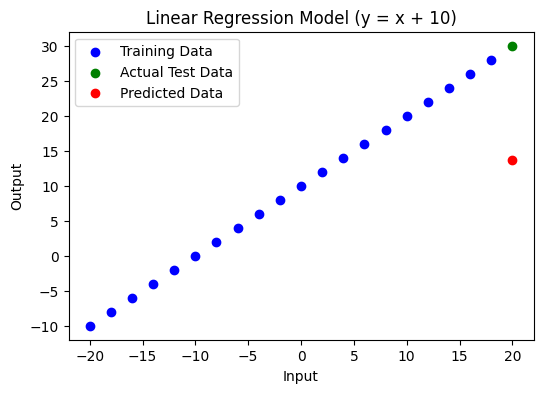

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Create simple linear dataset
inputs = np.arange(-20, 22, 2, dtype=np.float32)
outputs = inputs + 10

# Split into training and testing sets
train_inputs = inputs[:20]
train_outputs = outputs[:20]

test_inputs = inputs[20:]
test_outputs = outputs[20:]

# Build regression model
linear_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

# Compile model
linear_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="mae",
    metrics=["mae"]
)

# Train model
linear_model.fit(
    train_inputs,
    train_outputs,
    epochs=200,
    verbose=0
)

# Evaluate model
test_loss, test_mae = linear_model.evaluate(test_inputs, test_outputs, verbose=0)
print(f"Test MAE: {test_mae:.3f}")

# Make predictions
predictions = linear_model.predict(test_inputs, verbose=0).flatten()

# Plot results
plt.figure(figsize=(6, 4))

plt.scatter(train_inputs, train_outputs, color="blue", label="Training Data")
plt.scatter(test_inputs, test_outputs, color="green", label="Actual Test Data")
plt.scatter(test_inputs, predictions, color="red", label="Predicted Data")

plt.legend()
plt.title("Linear Regression Model (y = x + 10)")
plt.xlabel("Input")
plt.ylabel("Output")

plt.show()